# Import necessary libraries

In [52]:
%matplotlib inline
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow_datasets as tfds
import pathlib
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

# Set the default figure size for matplotlib
plt.rcParams['figure.figsize'] = (7,7) # Make the figures a bit bigger

# Load data and preprocess it

## Upload the data to drive:
Download the dataset from Brigthspace, and upload it to the content folder in Google Colab.


###Option 1: To avoid having to upload the dataset every time, you can upload the dataset to your google drive, and then connect this virtual machine to your drive, and make a copy of your data

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
!ls -R /content/drive/MyDrive/BrainCancer




/content/drive/MyDrive/BrainCancer:
2025_brain_cancer_classification.ipynb	BrainTumorDataset.zip


Replace the path /content/drive/MyDrive/Work/2025-CS3002/BrainTumorDataset.zip with your actual path where you copied the dataset in your drive.

In [55]:
!cp /content/drive/MyDrive/BrainCancer/BrainTumorDataset.zip /content/



###Option 2: Upload the zip archive in the Files section of your virtual machine, under /content/

###After the data is loaded, let's start processing it.

In [56]:
# After you have copied the data locally, point the dataset_url to the local path
dataset_url = '/content/BrainTumorDataset.zip'

In [57]:
import zipfile
import os

# Path to your local zip file
zip_path = dataset_url

# Path where you want to extract
out_path = "/content/"

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(out_path)

print("Extraction complete. Files are in:", out_path)


Extraction complete. Files are in: /content/


In [58]:
# Create a 'pathlib.Path' object for the downloaded archive
# Pathlib module offers classes representing filesystem paths with semantics
# appropriate for different operating systems.
# data_dir = pathlib.Path(archive).with_suffix('')

extract_dir = pathlib.Path(zip_path).with_suffix('')
# Now use Pathlib for further work
data_dir = pathlib.Path(extract_dir)

print("Data directory is:", data_dir)

Data directory is: /content/BrainTumorDataset


In [59]:
# Count the number of images in a specific directory
image_count = len(list(data_dir.glob('./Training/glioma/*.jpg')))
print(image_count)

500


In [60]:
# BEGIN YOUR CODE HERE

# Brain tumour dataset is split into train, validation and test folders. Inside those folders you will
# find additional folders: glioma, pituitary, notumor. You can explore the folders using
# 'Files' tab from the right hand side.
# Tip: use the len() function

# 1a. How many images do we have in training for positive glaucoma? How many for negative glaucoma?
#TRAINING SET
TrainG_count = len(list(data_dir.glob('./Training/glioma/*.jpg')))
print("Number of glioma in training set: " + str(TrainG_count))
TrainP_count = len(list(data_dir.glob('./Training/pituitary/*.jpg')))
print("Number of pituiatry in training set: " + str(TrainP_count))
TrainNT_count = len(list(data_dir.glob('./Training/notumor/*.jpg')))
print("Number of no tumor in training set: " + str(TrainNT_count))


# 1b. How about in the testing set?
#TESTING SET
TestG_count = len(list(data_dir.glob('./Testing/glioma/*.jpg')))
print("Number of glioma in testing set: " + str(TestG_count))
TestP_count = len(list(data_dir.glob('./Testing/pituitary/*.jpg')))
print("Number of no pituitary in testing set: " + str(TestP_count))
TestNT_count = len(list(data_dir.glob('./Testing/notumor/*.jpg')))
print("Number of no tumor in testing set: " + str(TestNT_count))

negative_pituitary = TestG_count + TestNT_count
print("number of negative pituitary images  =  " + str(negative_pituitary))

# 1c. How about in the validation set?
ValidationG_count = len(list(data_dir.glob('./Validation/glioma/*.jpg')))
print("Number of glioma in validation set: " + str(ValidationG_count))
ValidationP_count= len(list(data_dir.glob('./Validation/pituitary/*.jpg')))
print("Number of pituitary in validation set: " + str(ValidationP_count))
ValidationNT_count = len(list(data_dir.glob('./Validation/notumor/*.jpg')))
print("Number of no tumor in validation set: " + str(ValidationNT_count))

# Q. Is the dataset balanced or not?
#TESTING GLIOMA, Training Pituitary, Validation pituitary glioma and no tumor

positive_cases = TestG_count + TestP_count + TrainG_count + TrainP_count + ValidationG_count + ValidationP_count
print("number of positive glioma or pituitary images " + str(positive_cases))

negative_cases = TestNT_count + TrainNT_count + ValidationNT_count
print("number of negative no tumor iamges " + str(negative_cases))

##negative and positive images are roughly balanced however there are more no tumor images compared to glioma and pituiatry images in all three sets of the brain cancer dataset

# END YOUR CODE HERE

Number of glioma in training set: 500
Number of pituiatry in training set: 500
Number of no tumor in training set: 1550
Number of glioma in testing set: 300
Number of no pituitary in testing set: 300
Number of no tumor in testing set: 300
number of negative pituitary images  =  600
Number of glioma in validation set: 150
Number of pituitary in validation set: 150
Number of no tumor in validation set: 150
number of positive glioma or pituitary images 1900
number of negative no tumor iamges 2000


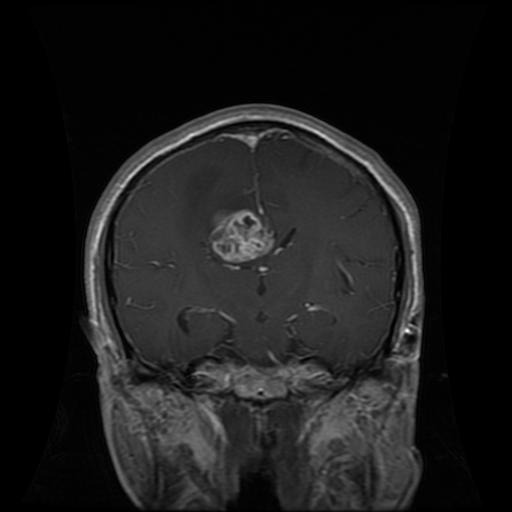

In [61]:
# Create a list of file paths for glaucoma images
positive_images = list(data_dir.glob('Training/glioma/*'))
# Open and display the first glaucoma image in the list
PIL.Image.open(str(positive_images[0]))

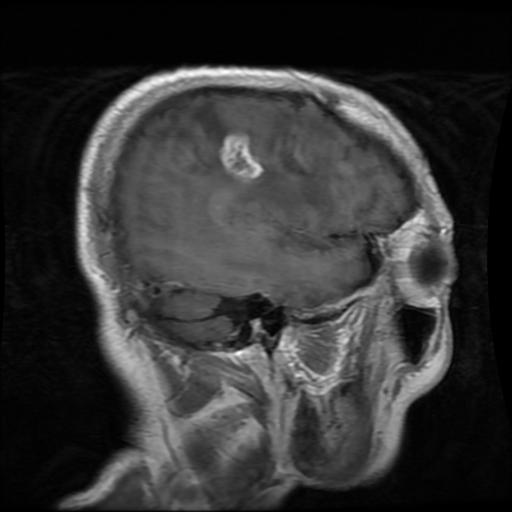

In [62]:
# BEGIN YOUR CODE HERE

# 2. Display a glioma image from the validation dataset
# Create a list of file paths for glioma images
gliomaV_images = list(data_dir.glob('Validation/glioma/*'))

# Open and display the first glioma image in the list
PIL.Image.open(str(gliomaV_images[0]))

# END YOUR CODE HERE

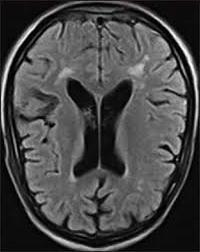

In [63]:
# BEGIN YOUR CODE HERE

# 2. Display a normal image from the validation dataset
# Create a list of file paths for the no tumour images
notumorV_images = list(data_dir.glob('Validation/notumor/*'))

# Open and display the first  image in the list
PIL.Image.open(str(notumorV_images[0]))

# END YOUR CODE HERE

# Define a deep learning model that will learn the differences between glioma, pituitary and normal brain images


In [64]:
# Define batch size and image dimensions for training
# BEGIN YOUR CODE HERE.

batch_size = 32
##theres almost 4000 grayscale images of resolution 512x512 so im using batch size 32 to balance training speed, stability, and memory use
img_height = 256
img_width = 256
##using a larger input size like 256x256 allows me to still keep detail when training the model, improving its ability to distinguish between the three classes

# END YOUR CODE HERE

In [65]:
train_data_dir  = os.path.join(data_dir,'Training')
valid_data_dir = os.path.join(data_dir,'Validation')
test_data_dir = os.path.join(data_dir,'Testing')

In [66]:
# Create a TensorFlow image dataset from a directory
#tensorflow image dataset loads images from disk in small batches instead of all at once so training is fatser and doesnt run out of memory
# BEGIN YOUR CODE HERE
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    seed=123, #seed parameter reproduces the same results, if not used model is different at every run and results are different
    image_size=(img_height,img_width),
    batch_size = batch_size,
    shuffle=True #dataset is randomly shuffled to avoid any overfitting in training, shuffling useful during learning stage not validation/testing
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_data_dir,
    seed=123,  #seed makes sure shuffle is consistent
    image_size=(img_height,img_width),
    batch_size = batch_size,
    shuffle=False
)

# END YOUR CODE HERE

Found 2550 files belonging to 3 classes.
Found 450 files belonging to 3 classes.


In [67]:
# Create a layer to normalise pixel values to the [0, 1] range.
normalization_layer = tf.keras.layers.Rescaling(1./255)
#images normally have a pixel value between 0 and 255 however these need to be normalised to the [0,1] range for neural networks
#creates a layer that divides every pixel by 255 to rescale into that range

In [68]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image), first_image[0][0])

0.0 1.0 tf.Tensor([0.09126142 0.09126142 0.09126142], shape=(3,), dtype=float32)


In [69]:
# BEGIN YOUR CODE HERE

num_classes = 3 #because there are three categories: glioma, pituitary and notumor

# END YOUR CODE HERE

In [70]:
# Define a tensorflow model using the tf.keras.Sequential class
# BEGIN YOUR CODE HERE

#tf.keras.Sequential = creates a step by step model where layers are stacked on top of each other and output from previous layer passed to the next
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    ##32 = number of kernels, each kernel is 3x3 pixels, activation='relu' means output and input not directly proportional/corresponding

    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    ##makes model faster and less prone to overfitting

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    ##another conv2D layer means model can learn more complex features, also more kernerls than first layer
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    ##sets % of neurons to zero randomly to prevent overfitting
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Flatten(),
    ##converts the feature maps to 1D vector
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    ##full connected layer where each neuron connects to all inputs from previous layer, 128 = no of neurons
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation=tf.nn.softmax)
])

# END YOUR CODE HERE

model.compile(
  optimizer='adam',  #updates weight during training
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), #measure how wrong the predictions of the model are
  metrics=['accuracy']) # Monitor accuracy (metrics) and F1 score during training



In [71]:
# Extract training labels
y_train = np.concatenate([y for x, y in train_ds], axis=0)
#collects a batch of labels,(y) for each batch of images,(x)

# Compute class weights
##because some classes contain less images than others
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.7), 1: np.float64(0.5483870967741935), 2: np.float64(1.7)}


In [72]:
# Train the model on the provided dataset for a specified number of epochs and modify the network architecture such that you maximise the accuracy.
# BEGIN YOUR CODE HERE

history = model.fit(train_ds, epochs=5, validation_data=valid_ds, class_weight=class_weights)

# END YOUR CODE HERE

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 109ms/step - accuracy: 0.8459 - loss: 6.7091 - val_accuracy: 0.7556 - val_loss: 0.7249
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9549 - loss: 0.1373 - val_accuracy: 0.8133 - val_loss: 0.5852
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.9686 - loss: 0.0860 - val_accuracy: 0.7422 - val_loss: 0.9215
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9718 - loss: 0.0738 - val_accuracy: 0.8200 - val_loss: 0.6456
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9804 - loss: 0.0503 - val_accuracy: 0.6400 - val_loss: 3.8967


In [73]:
from scipy.ndimage import gaussian_filter1d  # for smoothing

# function to plot loss/accuracy with trend lines
def plot_loss_accuracy(history, smooth_sigma=2):
    # Extract loss and accuracy values
    loss_values = history.history['loss']
    acc_values = history.history['accuracy']

    # Validation (if available)
    val_loss = history.history.get('val_loss')
    val_acc = history.history.get('val_accuracy')

    epochs = np.arange(1, len(loss_values) + 1)

    # --- Plot Training & Validation Loss ---
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss_values, marker='o', linestyle='-', color='b', alpha=0.5, label='Training Loss')
    plt.plot(epochs, gaussian_filter1d(loss_values, sigma=smooth_sigma), color='b', linewidth=2, label='Trend (Train)')

    if val_loss is not None:
        plt.plot(epochs, val_loss, marker='x', linestyle='--', color='r', alpha=0.5, label='Validation Loss')
        plt.plot(epochs, gaussian_filter1d(val_loss, sigma=smooth_sigma), color='r', linewidth=2, label='Trend (Val)')

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Over Epochs')
    plt.grid(True)
    plt.legend()

    # --- Plot Training & Validation Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc_values, marker='o', linestyle='-', color='g', alpha=0.5, label='Training Accuracy')
    plt.plot(epochs, gaussian_filter1d(acc_values, sigma=smooth_sigma), color='g', linewidth=2, label='Trend (Train)')

    if val_acc is not None:
        plt.plot(epochs, val_acc, marker='x', linestyle='--', color='orange', alpha=0.5, label='Validation Accuracy')
        plt.plot(epochs, gaussian_filter1d(val_acc, sigma=smooth_sigma), color='orange', linewidth=2, label='Trend (Val)')

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

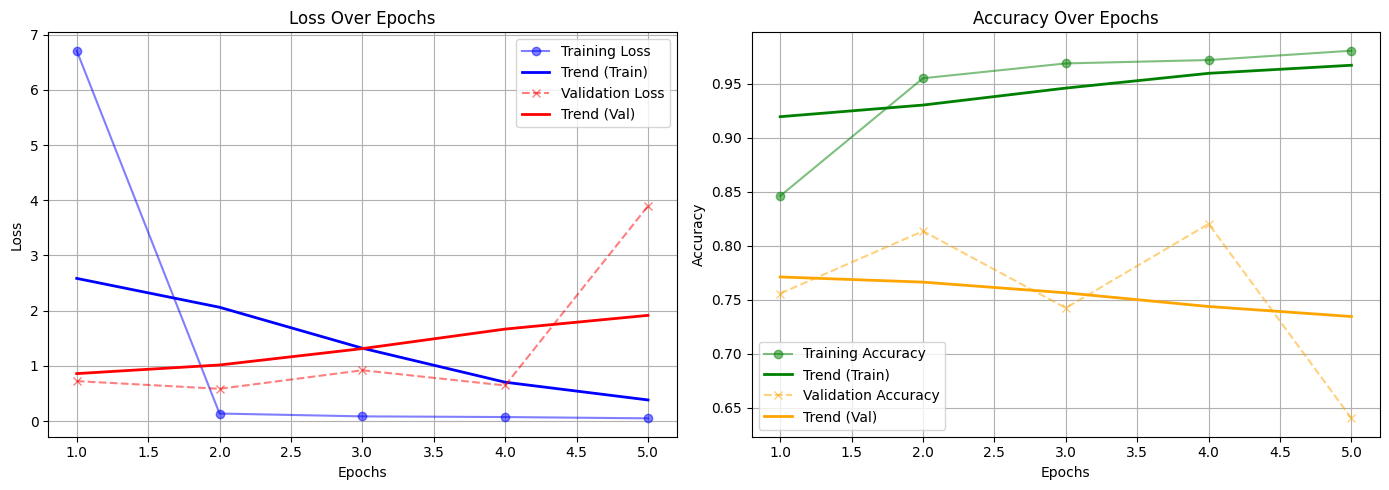

In [74]:
plot_loss_accuracy(history)

In [75]:
#load the testing dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_data_dir,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  shuffle=False   # 🔑 Ensure labels line up with predictions)
)
##loads test images, resizes them and puts into batches

Found 900 files belonging to 3 classes.


Test Loss: 2.8301
Test Accuracy: 0.7278
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step
['glioma', 'notumor', 'pituitary']
              precision    recall  f1-score   support

      glioma       0.97      0.66      0.79       300
     notumor       0.59      1.00      0.74       300
   pituitary       0.84      0.52      0.64       300

    accuracy                           0.73       900
   macro avg       0.80      0.73      0.72       900
weighted avg       0.80      0.73      0.72       900



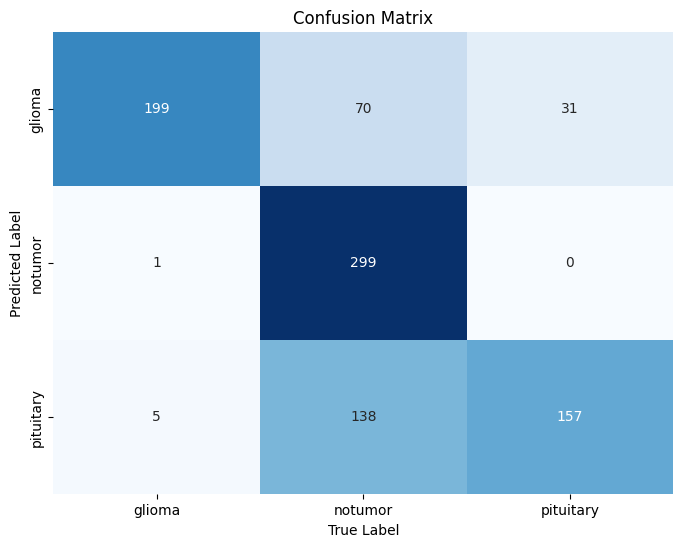

In [76]:
# Compute and plot the confusion matrix on the test dataset, display the confusion matrix, precision, recall and f1-score
# BEGIN YOUR CODE HERE

# Evaluate the trained model on the test data
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get the model's predictions on the test data
test_data_pred = model.predict(test_ds)  # Get probabilities
test_data_pred = np.argmax(test_data_pred, axis=1)  # Convert probabilities to class predictions

# Print a classification report (precision, recall, F1-score, support)
# Extract true labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)
class_names = test_ds.class_names
print(class_names)
print(classification_report(y_true, test_data_pred, target_names=class_names))

# Compute and plot the confusion matrix
conf_matrix = confusion_matrix(y_true, test_data_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,  xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.ylabel("Predicted Label")
plt.xlabel("True Label")
plt.show()

# END YOUR CODE HERE